In [14]:
import QsamplingFromLogical as qfl

Qubit Mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'anc1': 4, 'anc2': 5, 'anc3': 6, 'anc4': 7, 'anc5': 8}
The variable qubits: {'C', 'B', 'D', 'A'}


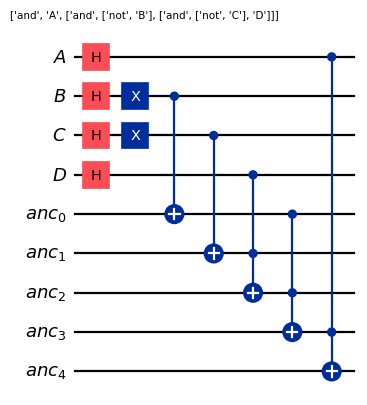

In [15]:
# Example Logical Expression
formula = ['and', 'A',['and',['not', 'B'],['and',['not', 'C'],'D']]]

# Generate Quantum Circuit with Dynamic Qubit Allocation
qc, qubits_map = qfl.logicaltoquantum(formula)
print("Qubit Mapping:", qubits_map)

variable_qubits = qfl.extractvariables(formula)
print("The variable qubits:", variable_qubits)

fig = figure()
ax = fig.add_subplot()

ax.set_title(formula, fontsize=7.5, loc = 'left')

qc.draw('mpl', ax = ax)  # Draw the circuit

In [16]:
good_state_prob = qfl.formula_probability(formula, variable_qubits)
print("The probability of obtaining state '1' is:", good_state_prob)

The probability of obtaining state '1' is: 0.0625


In [17]:
rounds, good_state_prob = qfl.amplification_rounds(formula, variable_qubits)
print("The probability of obtaining the good state is: P =", good_state_prob)
print("Thus the number of rotations needed for near perfect amplification is: k =", rounds)

The probability of obtaining the good state is: P = 0.0625
Thus the number of rotations needed for near perfect amplification is: k = 3


In [18]:
amplified_circuits = qfl.generate_amplified_circuits(qc, qfl.oracle_generate(qc, good_state_prob), 
                                                 qfl.diffusion_generate(qc), rounds)

In [19]:
# make a copy so original isn't modified
amplified_circuits_copy = amplified_circuits.copy()
amplified_circuits_copy

{0: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23ccdc0be80>,
 1: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23ccdf08c10>,
 2: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23ccdf66220>,
 3: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23ccdf666d0>}

In [20]:
sim = AerSimulator(method="matrix_product_state")
N_shots = 1000000  # number of measurements

circuit_measurements = {}
prob_values = {}
counts = {}
res = {}

for i, circ in amplified_circuits_copy.items():
    # add 1 classical bit to measure last qubit
    creg = ClassicalRegister(1)
    amplified_circuits_copy[i].add_register(creg)
    amplified_circuits_copy[i].measure(amplified_circuits_copy[i].num_qubits - 1, 0)

    # transpile
    circuit_measurements[i] = qis.transpile(amplified_circuits_copy[i], sim)

    # run simulation
    res[i] = sim.run(circuit_measurements[i], shots=N_shots, max_parallel_threads=16).result()
    counts[i] = res[i].get_counts()

    # normalize into probabilities
    prob_values[i] = {bit: count / N_shots for bit, count in counts[i].items()}

"""
for i in range (0, rounds):
    amplified_circuits[i].add_register(ClassicalRegister(1))
    amplified_circuits[i].measure(len(qubits_map)-1, 0)
    circuit_measurements[i] = qis.transpile(amplified_circuits[i], sim)

    res = sim.run(circuit_measurements, shots=N_shots, max_parallel_threads = 16).result()
    coun = res.get_counts()

    prob_values[i] = {bitstring: count / N_shots for bitstring, count in coun.items()}
"""

'\nfor i in range (0, rounds):\n    amplified_circuits[i].add_register(ClassicalRegister(1))\n    amplified_circuits[i].measure(len(qubits_map)-1, 0)\n    circuit_measurements[i] = qis.transpile(amplified_circuits[i], sim)\n\n    res = sim.run(circuit_measurements, shots=N_shots, max_parallel_threads = 16).result()\n    coun = res.get_counts()\n\n    prob_values[i] = {bitstring: count / N_shots for bitstring, count in coun.items()}\n'

In [21]:
prob_values

{0: {'0': 0.937533, '1': 0.062467},
 1: {'1': 0.471704, '0': 0.528296},
 2: {'1': 0.908285, '0': 0.091715},
 3: {'1': 0.961169, '0': 0.038831}}

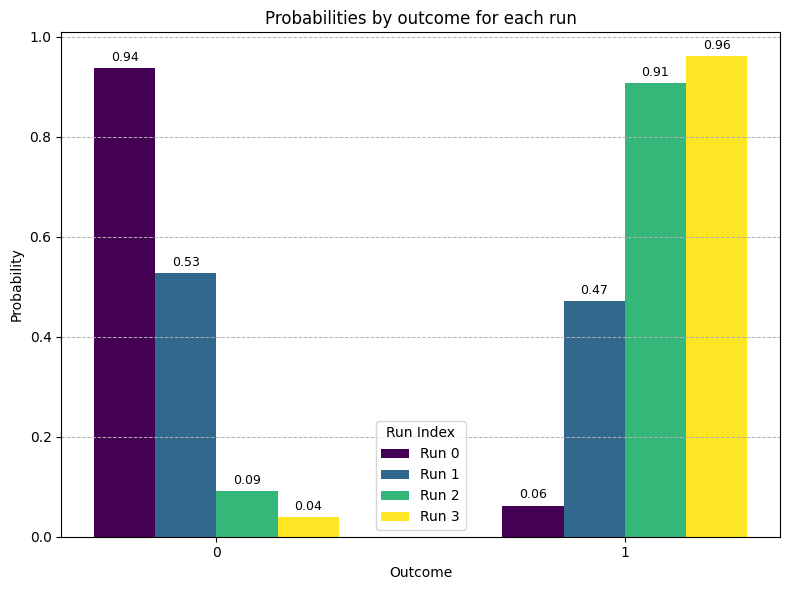

In [22]:
outcomes = ['0', '1']
runs = sorted(prob_values.keys())
num_runs = len(runs)
width = 0.15

x = np.arange(len(outcomes))

# Choose a color palette
colors = plt.cm.viridis(np.linspace(0, 1, num_runs))

fig, ax = plt.subplots(figsize=(8, 6))

bars = []
for idx, run in enumerate(runs):
    bar_values = [prob_values[run].get(o, 0) for o in outcomes]
    b = ax.bar(x + width*idx - width*num_runs/2 + width/2, bar_values, width, label=f'Run {run}', color=colors[idx])
    bars.append(b)

# Add bar labels
for b in bars:
    for rect in b:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),   # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(outcomes)
ax.set_xlabel('Outcome')
ax.set_ylabel('Probability')
ax.set_title('Probabilities by outcome for each run')
ax.grid(axis='y', linestyle='--', linewidth=0.7)
ax.legend(title='Run Index')

plt.tight_layout()
plt.show()


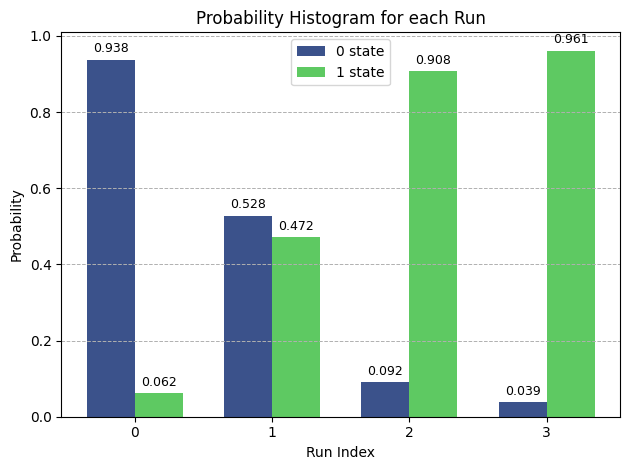

In [23]:
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(prob_values.keys())  # run indices
x = np.arange(len(labels))           # x positions

probs_0 = [prob_values[i].get('0', 0) for i in labels]
probs_1 = [prob_values[i].get('1', 0) for i in labels]

width = 0.35

# Use continuous colormap for the two bar sets
colors = plt.cm.viridis(np.linspace(0.25, 0.75, 2))

fig, ax = plt.subplots()
rects0 = ax.bar(x - width/2, probs_0, width, label='0 state', color=colors[0])
rects1 = ax.bar(x + width/2, probs_1, width, label='1 state', color=colors[1])

# Add bar labels
for rect in rects0:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Run Index')
ax.set_ylabel('Probability')
ax.set_title('Probability Histogram for each Run')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add grid mesh lines on y axis for readability
ax.grid(axis='y', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()
